# eRank Training Curves

Compare token-level and pooled effective-rank trajectories across the four collapse-investigation runs. The 100 Hz and 12-lead runs are dev-preset ablations; the final-preset run is included as the larger reference model.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = ROOT.parent
if not (ROOT / "src" / "encoder.py").is_file():
    ROOT = Path("/home/aimakeradmin/shady/TS-JEPA")

sys.path.insert(0, str(ROOT))
from collapse_investigation.analysis_utils import RUN_COLORS, RUN_LABELS

CHECKPOINT_ROOT = ROOT / "checkpoints"
FIG_DIR = ROOT / "collapse_investigation" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUNS = ["final_preset_final", "dev_preset_final", "dev_100hz", "dev_12lead", "dev_100hz_ffn"]
metrics = {
    run: pd.read_csv(CHECKPOINT_ROOT / run / "metrics.csv")
    for run in RUNS
}

for run, df in metrics.items():
    print(run, df.shape, "epochs", int(df["epoch"].min()), "to", int(df["epoch"].max()))

final_preset_final (102, 13) epochs 0 to 99
dev_preset_final (100, 13) epochs 0 to 99
dev_100hz (100, 13) epochs 0 to 99
dev_12lead (100, 13) epochs 0 to 99
dev_100hz_ffn (100, 13) epochs 0 to 99


In [2]:
def summarize_run(run: str, df: pd.DataFrame) -> dict[str, float | int | str]:
    best_token = df.loc[df["erank_ctx_token"].idxmax()]
    best_pool = df.loc[df["erank_ctx_pool"].idxmax()]
    best_val = df.loc[df["val_loss"].idxmin()]
    final = df.iloc[-1]
    return {
        "run": run,
        "label": RUN_LABELS[run],
        "max_token_erank": best_token["erank_ctx_token"],
        "max_token_epoch": int(best_token["epoch"]),
        "max_pooled_erank": best_pool["erank_ctx_pool"],
        "max_pooled_epoch": int(best_pool["epoch"]),
        "best_val_loss": best_val["val_loss"],
        "best_val_epoch": int(best_val["epoch"]),
        "final_token_erank": final["erank_ctx_token"],
        "final_pooled_erank": final["erank_ctx_pool"],
        "collapse_alarm_epochs": int(df["collapse_alarm"].sum()),
        "num_epochs": len(df),
    }

summary = pd.DataFrame([summarize_run(run, df) for run, df in metrics.items()])
summary

,run,label,max_token_erank,max_token_epoch,max_pooled_erank,max_pooled_epoch,best_val_loss,best_val_epoch,final_token_erank,final_pooled_erank,collapse_alarm_epochs,num_epochs
0,final_preset_final,"Final preset, 8 leads, 250 Hz",170.0821,28,83.2517,24,0.223204,3,114.6980,57.8779,4,102
1,dev_preset_final,"Dev preset, 8 leads, 250 Hz",68.6760,28,32.6268,23,0.176137,96,60.0957,27.1100,6,100
2,dev_100hz,"Dev preset, 8 leads, 100 Hz",25.6684,80,21.4666,0,0.243456,7,25.5066,12.2714,29,100
3,dev_12lead,"Dev preset, 12 leads, 250 Hz",70.4657,37,22.9942,32,0.179063,91,50.4839,13.9555,12,100
4,dev_100hz_ffn,"Dev preset, FFN tokenizer, 8 leads, 100 Hz",19.1736,99,15.7829,0,0.219924,6,19.1736,7.9109,98,100


saved /home/aimakeradmin/shady/TS-JEPA/collapse_investigation/figures/erank_token_training_curves.png


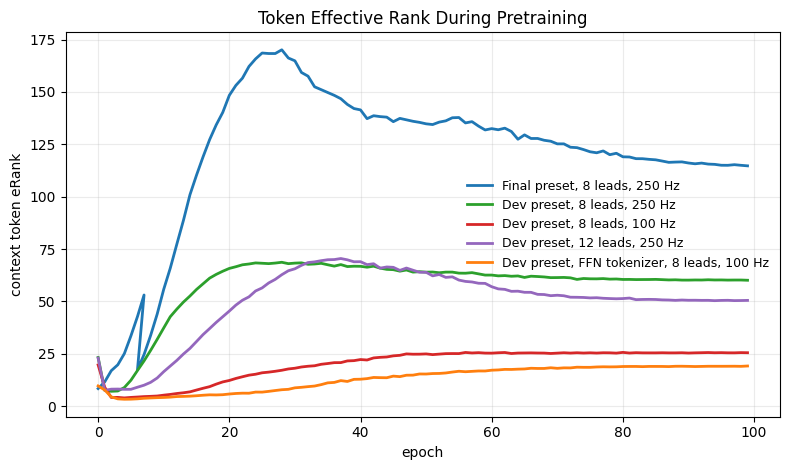

In [3]:
def plot_erank(column: str, title: str, ylabel: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    for run in RUNS:
        df = metrics[run]
        ax.plot(
            df["epoch"],
            df[column],
            label=RUN_LABELS[run],
            color=RUN_COLORS[run],
            linewidth=2,
        )
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print("saved", out)
    plt.show()

plot_erank(
    "erank_ctx_token",
    "Token Effective Rank During Pretraining",
    "context token eRank",
    "erank_token_training_curves.png",
)

saved /home/aimakeradmin/shady/TS-JEPA/collapse_investigation/figures/erank_pooled_training_curves.png


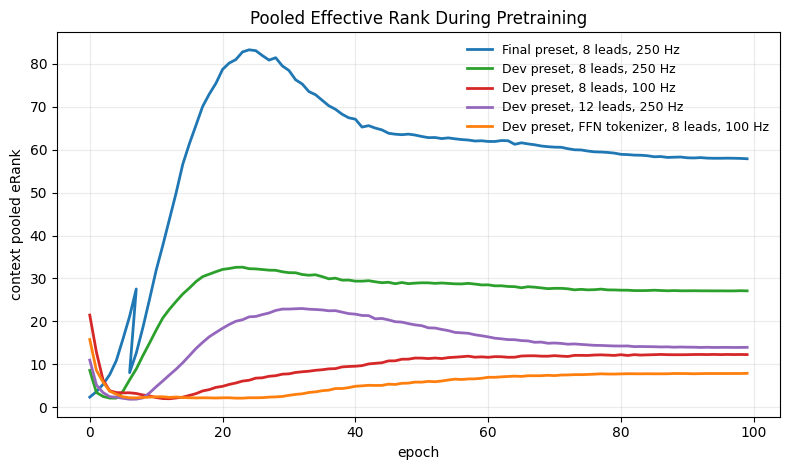

In [4]:
plot_erank(
    "erank_ctx_pool",
    "Pooled Effective Rank During Pretraining",
    "context pooled eRank",
    "erank_pooled_training_curves.png",
)

In [5]:
summary_path = ROOT / "collapse_investigation" / "erank_summary.csv"
summary.to_csv(summary_path, index=False)
print("saved", summary_path)
summary[[
    "label",
    "max_token_erank",
    "max_token_epoch",
    "max_pooled_erank",
    "max_pooled_epoch",
    "best_val_loss",
    "best_val_epoch",
    "final_token_erank",
    "final_pooled_erank",
    "collapse_alarm_epochs",
]]

saved /home/aimakeradmin/shady/TS-JEPA/collapse_investigation/erank_summary.csv


,label,max_token_erank,max_token_epoch,max_pooled_erank,max_pooled_epoch,best_val_loss,best_val_epoch,final_token_erank,final_pooled_erank,collapse_alarm_epochs
0,"Final preset, 8 leads, 250 Hz",170.0821,28,83.2517,24,0.223204,3,114.6980,57.8779,4
1,"Dev preset, 8 leads, 250 Hz",68.6760,28,32.6268,23,0.176137,96,60.0957,27.1100,6
2,"Dev preset, 8 leads, 100 Hz",25.6684,80,21.4666,0,0.243456,7,25.5066,12.2714,29
3,"Dev preset, 12 leads, 250 Hz",70.4657,37,22.9942,32,0.179063,91,50.4839,13.9555,12
4,"Dev preset, FFN tokenizer, 8 leads, 100 Hz",19.1736,99,15.7829,0,0.219924,6,19.1736,7.9109,98
